In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

c:\Users\arthu\anaconda3\lib\site-packages\pandas\core\computation\expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
c:\Users\arthu\anaconda3\lib\site-packages\pandas\core\arrays\masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.4' currently installed).
  from pandas.core import (
c:\Users\arthu\anaconda3\lib\site-packages\scipy\__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.26.2
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [3]:
df = pd.read_csv("vendas_analitica.csv")

df.head()

,country,city,data_pedido,gender,order_id,product_brand,product_category,product_id,product_name,produtos_retail_price,receita,status,Soma de user_id
0,Australia,Adelaide,2021-07-19 00:00:00,F,114328,Vanity Fair,Plus,15767,Vanity Fair Women's Full Figure Back Smoother Bra,34.000000,34.000000,Complete,91470
1,Australia,Adelaide,2021-09-30 00:00:00,F,63096,Adrianna Papell,Dresses,3890,Adrianna Papell Women's Draped Jersey Dress,44.970001,44.970001,Complete,50380
2,Australia,Adelaide,2022-09-21 00:00:00,M,113691,Fruit of the Loom,Underwear,26342,Fruit Of The Loom Men's Woven Boxer,25.000000,25.000000,Complete,90962
3,Australia,Adelaide,2023-01-20 00:00:00,F,63098,Activewear Apparel,Fashion Hoodies & Sweatshirts,1947,Cheer Heart Zipper Hoodie,41.990002,41.990002,Complete,50380
4,Australia,Adelaide,2023-03-05 00:00:00,F,94880,Pendleton,Blazers & Jackets,7791,Pendleton Women's 3/4 Sleeve Savanna Sateen Ja...,65.129997,65.129997,Complete,75833


In [ ]:
# Alterando o nome da coluna "Soma de user_id" para "user_id"
df.rename(columns={
    'Soma de user_id':'user_id'
}, inplace=True)

In [ ]:
# Criando métricas de datas como ano e mês
df['data_pedido'] = pd.to_datetime(df['data_pedido'])

df['ano'] = df['data_pedido'].dt.year
df['mes'] = df['data_pedido'].dt.to_period('M')

In [ ]:
# Filtrando para analisar apenas pedidos que possuem status de completos
df = df[df['status'] == 'Complete']

In [ ]:
# Exibindo métricas para primeira análise
print("Receita Total:", df['receita'].sum())
print("Ticket Médio:", df['receita'].mean())
print("Pedidos:", df['order_id'].nunique())
print("Clientes:", df['user_id'].nunique())

Receita Total: 1782746.741456747
Ticket Médio: 59.42687227763415
Pedidos: 20751
Clientes: 18380


### Detalhamento de Métricas Considerando Pedidos com status de concluídos (valores em dolar):
 - Receita Total: 1782746.741456747
 - Ticket Médio: 59.42687227763415
 - Total de Pedidos: 20751
 - Total de Clientes: 18380


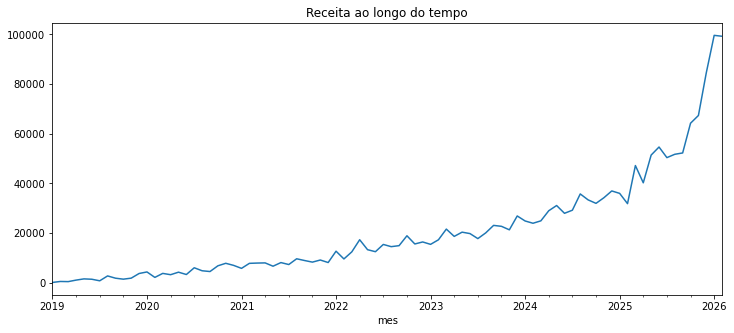

In [28]:
receita_mes = df.groupby('mes')['receita'].sum()

receita_mes.plot(figsize=(12,5), title="Receita ao longo do tempo")
plt.show()

###  Receita ao longo do tempo:
 - Tendência de crescimento de receita em todo intervalo de dados
 - A receita mostra uma grandativa tendência de crescimento até o final de 2025, a receita apresenta intervalos de queda, mas mantem o crescimento ao longo do tempo
 - A receita apresenta crescimento exponencial a partir de 2026

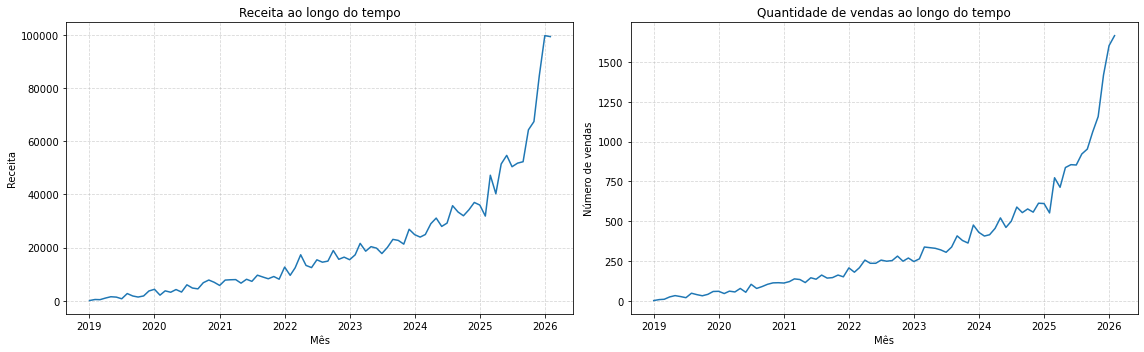

In [54]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ===============================
# Agregações
# ===============================

receita_mes = df.groupby('mes')['receita'].sum()
vendas_mes = df.groupby('mes')['order_id'].count()

# ✅ Converter Period -> datetime
if isinstance(receita_mes.index, pd.PeriodIndex):
    receita_mes.index = receita_mes.index.to_timestamp()
    vendas_mes.index = vendas_mes.index.to_timestamp()

# ✅ Converter para arrays NUMPY puros (CORREÇÃO DO ERRO)
x1 = np.array(receita_mes.index.to_pydatetime())
y1 = np.array(receita_mes.values, dtype=float)

x2 = np.array(vendas_mes.index.to_pydatetime())
y2 = np.array(vendas_mes.values, dtype=float)

# ===============================
# Plot
# ===============================

fig, axes = plt.subplots(1, 2, figsize=(16,5))

# ----- Receita -----
axes[0].plot(x1, y1)
axes[0].set_title("Receita ao longo do tempo")
axes[0].set_xlabel("Mês")
axes[0].set_ylabel("Receita")
axes[0].grid(True, linestyle='--', alpha=0.5)

# ----- Vendas -----
axes[1].plot(x2, y2)
axes[1].set_title("Quantidade de vendas ao longo do tempo")
axes[1].set_xlabel("Mês")
axes[1].set_ylabel("Número de vendas")
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

### Receita ao Longo do Tempo vs Quantidade de Vendas ao Longo do Tempo
 - Tanto a receita como a quantidade de vendas apresenta a mesma tendência de crescimento, sendo visível o crescimento exponencial em 2026

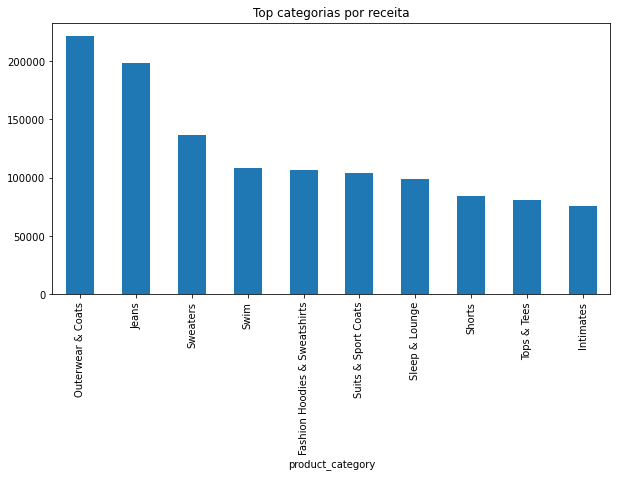

In [40]:
categoria = (
    df.groupby('product_category')['receita']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

categoria.plot(kind='bar', figsize=(10,5))
plt.title("Top categorias por receita")
plt.show()

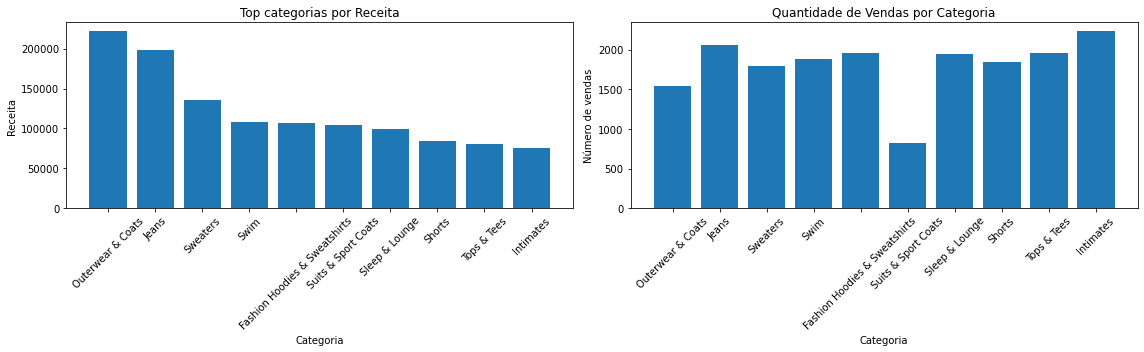

In [55]:
import matplotlib.pyplot as plt
import numpy as np

# ===============================
# Agregações por categoria
# ===============================

categoria_receita = (
    df.groupby('product_category')['receita']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

categoria_vendas = (
    df.groupby('product_category')['order_id']
    .count()
    .reindex(categoria_receita.index)  # mesma ordem da receita
)

# ✅ Converter para numpy puro (evita erro numpy 2)
x = np.array(categoria_receita.index.astype(str))

y_receita = np.array(categoria_receita.values, dtype=float)
y_vendas = np.array(categoria_vendas.values, dtype=float)

# ===============================
# Criar figura
# ===============================

fig, axes = plt.subplots(1, 2, figsize=(16,5))

# ----- Receita -----
axes[0].bar(x, y_receita)

axes[0].set_title("Top categorias por Receita")
axes[0].set_xlabel("Categoria")
axes[0].set_ylabel("Receita")
axes[0].tick_params(axis='x', rotation=45)

# ----- Quantidade de vendas -----
axes[1].bar(x, y_vendas)

axes[1].set_title("Quantidade de Vendas por Categoria")
axes[1].set_xlabel("Categoria")
axes[1].set_ylabel("Número de vendas")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### Top Categorias por Receita vs Quantidade de Vendas por Categoria
 - Analisando o gráfico referente a receita, é possível concluir que as categorias "Outerwear & Coats" e "Jeans" representam a maior parte da receita, enquantos os demais itens se mostram equiparados.
 - Analisando o gráfico referente a quantidade de vendas, é possível ver que as categorias que possuem a maior parte da receita também são responsáveis por grande parte do total de vendas.
 - A categoria que possui a menor renda é também o produto mais vendido.

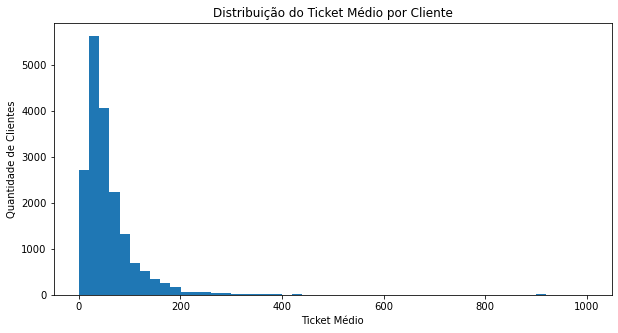

In [41]:
ticket_cliente = df.groupby('user_id')['receita'].mean()

plt.figure(figsize=(10,5))
plt.hist(ticket_cliente, bins=50)

plt.title("Distribuição do Ticket Médio por Cliente")
plt.xlabel("Ticket Médio")
plt.ylabel("Quantidade de Clientes")

plt.show()

### Principais Características observadas:
 - Forte concentração de clientes com ticket médio baixo a moderado.
 - Cauda longa à direita indicando poucos clientes com ticket extremamente alto.
 - Presença clara de outliers acima de ~300 e chegando próximo de 1000.(Isso indica que a receita não é distribuída uniformemente entre os clientes)
 - Distribuição não normal.(A maioria dos clientes possui baixo gasto médio, enquanto poucos clientes concentram valores elevados.)

**Consequências**:
 - A média provavelmente está inflada pelos grandes compradores.
 - A mediana representa melhor o comportamento típico do cliente.
 - Pequena parcela dos clientes gera grande parte da receita.

 **Insight**
  - A distribuição do ticket médio demonstra alta concentração de receita em uma pequena parcela de clientes com elevado poder de compra. Estratégias de retenção e personalização voltadas para esses clientes podem gerar impacto significativo na receita total, enquanto iniciativas de aumento de ticket médio devem focar na grande base de clientes de baixo valor.

In [42]:
grupos = [
    g['receita'].values
    for name, g in df.groupby('product_category')
]

anova = stats.f_oneway(*grupos)

print("P-value:", anova.pvalue)

#caso p < 0.5 as categorias impactam na receita

P-value: 0.0


### **Análise Estatística — ANOVA por Categoria de Produto**

**Resultado**
 - A receita média difere significativamente entre as categorias de produtos.

 - **H₀ (Hipótese nula): todas as categorias possuem a mesma média de receita.**
 - **H₁ (Hipótese alternativa): pelo menos uma categoria possui média diferente.**

**Resultado Obtido**
 - p < 0.000001
 - Como o valor obtido é menor que 0.05, a hipótese nula é rejeitada. Portanto, existe diferença estatisticamente significativa na receita média entre as categorias de produtos.
 - A categoria do produto impacta diretamente a receita.

**Conclusão**
 - Algumas categorias geram tickets médios maiores.
 - Outras dependem mais de volume.
 - O mix de produtos influencia diretamente o faturamento.
 - A performance financeira não é homogênea entre categorias. Logo, decisões estratégicas não devem tratar produtos igualmente.

 **Insight**
  - O teste ANOVA indicou diferença estatisticamente significativa entre as receitas médias das categorias de produtos (p < 0.001), evidenciando que o mix de categorias exerce influência direta no desempenho financeiro. Esse resultado sugere a necessidade de estratégias comerciais segmentadas por categoria, priorizando produtos de maior valor agregado e revisando categorias com menor performance.


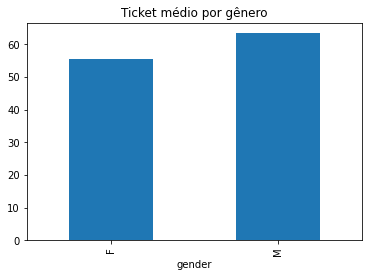

In [43]:
genero_receita = df.groupby('gender')['receita'].mean()

genero_receita.plot(kind='bar')
plt.title("Ticket médio por gênero")
plt.show()

### **Ticket Médio por Gênero**

**Insight**
 - A análise do ticket médio por gênero indica diferenças no comportamento de consumo entre os grupos, com clientes do gênero masculino apresentando maior valor médio por transação. O resultado sugere oportunidades para estratégias comerciais segmentadas, incluindo ações de upsell para perfis de maior ticket e iniciativas voltadas ao aumento do valor médio do carrinho para os demais segmentos.

In [44]:
X = df[['produtos_retail_price']]
y = df['receita']

model = LinearRegression()
model.fit(X, y)

print("Coeficiente:", model.coef_[0])

Coeficiente: 1.0


In [45]:
rfm = df.groupby('user_id').agg({
    'receita':'sum',
    'order_id':'count'
})

rfm.columns = ['valor_total','frequencia']

In [46]:
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm)

In [47]:
kmeans = KMeans(n_clusters=4, random_state=42)
rfm['cluster'] = kmeans.fit_predict(rfm_scaled)

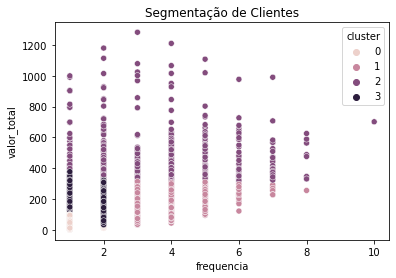

In [48]:
sns.scatterplot(
    data=rfm,
    x='frequencia',
    y='valor_total',
    hue='cluster'
)

plt.title("Segmentação de Clientes")
plt.show()

### **Análise - Segmentação de Clientes**

**Principais Observações**
 - Existe clara separação entre grupos de clientes.
 - A relação entre frequência e valor total não é linear.
 - Clientes com mesma frequência podem gerar receitas muito diferentes.

**Conclusão Principais Observações**
 - Isso confirma que frequência sozinha não explica valor do cliente.

**Interpretação dos clusters**
 - Mesmo sem os centróides explícitos, o padrão visual permite identificar perfis.

**Cluster 0 — Clientes de baixo valor**
 - **Características:**
    - baixa frequência
    - baixo valor total
    - maioria da base

 - **Perfil**
    - compradores ocasionais
    - baixa fidelização

 - **Estratégia**
    - campanhas de ativação
    - cupons de primeira recompra
    - onboarding melhorado


**Cluster 1 — Clientes em crescimento**
 - **Características:**
    - frequência moderada
    - valor intermediário
    - Este é o cluster com maior ROI potencial

 - **Perfil**
    - clientes com potencial de evolução

 - **Estratégia**
    - cross-sell
    - recomendações personalizadas
    - programas de pontos


**Cluster 2 — Clientes de alto valor**
 - **Características:**
    - alto valor total
    - frequência média/alta

 - **Perfil**
    - clientes recorrentes e lucrativos

 - **Estratégia**
    - retenção prioritária
    - benefícios exclusivos
    - early access a produtos


**Cluster 3 — Premium / Power Users**
 - **Características:**
    - alto valor mesmo com menor frequência (ou extremos)
    - presença de outliers positivos

 - **Perfil**
    - grandes compradores
    - impacto desproporcional na receita

 - **Estratégia**
    - tratamento VIP
    - suporte prioritário
    - personalização avançada


**Insight Estratégico Chave**
 - Revelado um padrão onde o valor do cliente multidimensional.
 - Clientes podem gerar alto valor por muitas compras (alta frequência), poucas compras de alto ticket e combinação dos dois.


**Insight Executivo**
 - A empresa não possui uma base homogênea.
 - Operação com múltiplos perfis econômicos simultaneamente:
  - massa de baixo valor (volume)
  - segmento intermediário escalável
  - pequena elite altamente lucrativa
 - Estratégias únicas para todos os clientes seriam ineficientes.

**Próximos Passos:**
 - marketing segmentado.
 - priorização de CAC (custo de aquisição).
 - retenção orientada por valor.
 - personalização de ofertas.



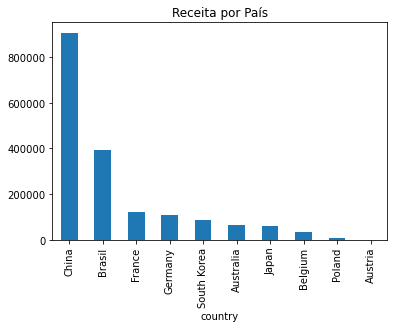

In [49]:
pais = df.groupby('country')['receita'].sum().sort_values(ascending=False).head(10)

pais.plot(kind='bar')
plt.title("Receita por País")
plt.show()

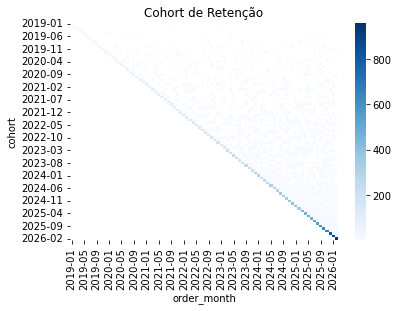

In [50]:
df['order_month'] = df['data_pedido'].dt.to_period('M')

cohort = df.groupby('user_id')['order_month'].min().reset_index()
cohort.columns = ['user_id','cohort']

df = df.merge(cohort, on='user_id')

retencao = df.groupby(['cohort','order_month'])['user_id'].nunique().unstack()

sns.heatmap(retencao, cmap='Blues')
plt.title("Cohort de Retenção")
plt.show()

### **Análise — Cohort de Retenção de Cliente**

**Objetivo da Análise**
 - O gráfico apresenta uma análise de coorte, utilizada para acompanhar o comportamento de retenção dos clientes ao longo do tempo.
    - Eixo Y (Cohort): mês da primeira compra do cliente.
    - Eixo X (order_month): meses subsequentes de atividade.
    - Intensidade da cor: quantidade de clientes ativos naquele período.
    - Cada linha representa uma geração de clientes acompanhada mês a mês após a aquisição.

**Resultados**
 - Forte concentração na diagonal principal.
 - Redução gradual da intensidade ao longo do tempo.
 - Pouca permanência prolongada em coortes antigas.

**Conclusão**
 - A base apresenta queda natural de retenção após a aquisição, comportamento comum em e-commerce e produtos transacionais.

**Interpretação do padrão diagonal**
 - Diagonal mais escura:
    - o mês inicial de compra (100% da coorte ativa).
    - maior volume de novos clientes entrando continuamente.
 - À medida que avançamos para a direita:
    - ocorre churn progressivo.
    - menos clientes retornam para novas compras.
 - Conclusão:
    - A empresa depende fortemente de aquisição contínua.


**Análise temporal (evolução das coortes)**
 - Coortes mais recentes (2024–2026):
    - apresentam maior intensidade inicial
    - indicam aumento na aquisição de clientes.
    - porém seguem padrão semelhante de queda.
 - Conclusão:
    - Houve crescimento de entrada de clientes, mas não melhoria estrutural da retenção.

**Estratégias Recomendadas**
 - **Curto Prazo:**
    - campanhas de recompra até 30 dias
    - e-mails pós-compra automatizados.
    - cupons de segunda compra.
- **Médio Prazo:**
    - programa de fidelidade.
    - recomendações personalizadas.
    - assinatura ou recorrência.
- **Longo Prazo:**
    - segmentação baseada em LTV.
    - personalização por cluster (conectar com sua análise anterior).


**Insight**
 - A análise de coorte revelou padrão consistente de queda de retenção após o primeiro período de compra, indicando dependência significativa da aquisição de novos clientes para sustentar o crescimento. Apesar do aumento no volume de novas coortes ao longo do tempo, não foi observada melhoria estrutural na retenção, sugerindo oportunidades estratégicas em iniciativas de fidelização e aumento do lifetime value.




### **Data Science - Previsão de Churn de Clientes**

In [59]:
## Preparação da base de dados
import pandas as pd
import numpy as np

# renomear colunas
df = df.rename(columns={
    'Soma de user_id': 'user_id',
    'data_pedido': 'order_date'
})

# tipo correto
df['order_date'] = pd.to_datetime(df['order_date'])

df.head()

,country,city,order_date,gender,order_id,product_brand,product_category,product_id,product_name,produtos_retail_price,receita,status,user_id,ano,mes,order_month,cohort_x,cohort_y,cohort
0,Australia,Adelaide,2021-07-19,F,114328,Vanity Fair,Plus,15767,Vanity Fair Women's Full Figure Back Smoother Bra,34.000000,34.000000,Complete,91470,2021,2021-07,2021-07,2021-07,2021-07,2021-07
1,Australia,Adelaide,2021-09-30,F,63096,Adrianna Papell,Dresses,3890,Adrianna Papell Women's Draped Jersey Dress,44.970001,44.970001,Complete,50380,2021,2021-09,2021-09,2021-09,2021-09,2021-09
2,Australia,Adelaide,2022-09-21,M,113691,Fruit of the Loom,Underwear,26342,Fruit Of The Loom Men's Woven Boxer,25.000000,25.000000,Complete,90962,2022,2022-09,2022-09,2022-09,2022-09,2022-09
3,Australia,Adelaide,2023-01-20,F,63098,Activewear Apparel,Fashion Hoodies & Sweatshirts,1947,Cheer Heart Zipper Hoodie,41.990002,41.990002,Complete,50380,2023,2023-01,2023-01,2021-09,2021-09,2021-09
4,Australia,Adelaide,2023-03-05,F,94880,Pendleton,Blazers & Jackets,7791,Pendleton Women's 3/4 Sleeve Savanna Sateen Ja...,65.129997,65.129997,Complete,75833,2023,2023-03,2023-03,2023-03,2023-03,2023-03


### **Objetivo: Prever se um pedido será de ALTO VALOR**
 - Responde as seguinte perguntas:
    - quais clientes geram maior receita?
    - quais categorias impulsionam vendas premium?
    - quando ocorre compra de alto ticket?

In [60]:
## Features temporais
df['mes'] = df['order_date'].dt.month
df['ano'] = df['order_date'].dt.year
df['dia_semana'] = df['order_date'].dt.dayofweek
df['fim_semana'] = (df['dia_semana'] >= 5).astype(int)

In [61]:
## Comportamento do Cliente
df['freq_cliente'] = (
    df.groupby('user_id')['order_id']
      .transform('nunique')
)

df['ticket_medio_cliente'] = (
    df.groupby('user_id')['receita']
      .transform('mean')
)

In [62]:
## Popularidade da Categoria
df['freq_cliente'] = (
    df.groupby('user_id')['order_id']
      .transform('nunique')
)

df['ticket_medio_cliente'] = (
    df.groupby('user_id')['receita']
      .transform('mean')
)

In [63]:
## Criando variável target
## Alto valor = top 25% da receita
limite = df['receita'].quantile(0.75)

df['alto_valor'] = (df['receita'] >= limite).astype(int)

print("Threshold:", limite)

Threshold: 69.94999694824219


In [66]:
## Selecionando Variáveis do modelo
# Popularidade da categoria (quantidade de vendas por categoria)
df['popularidade_categoria'] = (
    df.groupby('product_category')['order_id']
      .transform('count')
)


model_df = df[features + ['alto_valor']].dropna()

In [67]:
# tempo
df['mes'] = df['order_date'].dt.month
df['dia_semana'] = df['order_date'].dt.dayofweek
df['fim_semana'] = (df['dia_semana'] >= 5).astype(int)

# comportamento cliente
df['freq_cliente'] = df.groupby('user_id')['order_id'].transform('nunique')
df['ticket_medio_cliente'] = df.groupby('user_id')['receita'].transform('mean')

# produto
df['popularidade_categoria'] = (
    df.groupby('product_category')['order_id']
      .transform('count')
)

In [69]:
## Selecionando Variáveis do modelo
features = [
    'produtos_retail_price',
    'mes',
    'dia_semana',
    'fim_semana',
    'freq_cliente',
    'ticket_medio_cliente',
    'popularidade_categoria',
    'gender',
    'country',
    'product_category'
]

model_df = df[features + ['alto_valor']].dropna()

In [70]:
## Encoding automático
model_df = pd.get_dummies(
    model_df,
    drop_first=True
)

In [71]:
## Split
from sklearn.model_selection import train_test_split

X = model_df.drop('alto_valor', axis=1)
y = model_df['alto_valor']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [72]:
## Modelo Random Forest
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

RandomForestClassifier(max_depth=12, n_estimators=300, n_jobs=-1,
                       random_state=42)

In [73]:
## Avaliação
from sklearn.metrics import classification_report

pred = model.predict(X_test)

print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4483
           1       1.00      1.00      1.00      1517

    accuracy                           1.00      6000
   macro avg       1.00      1.00      1.00      6000
weighted avg       1.00      1.00      1.00      6000



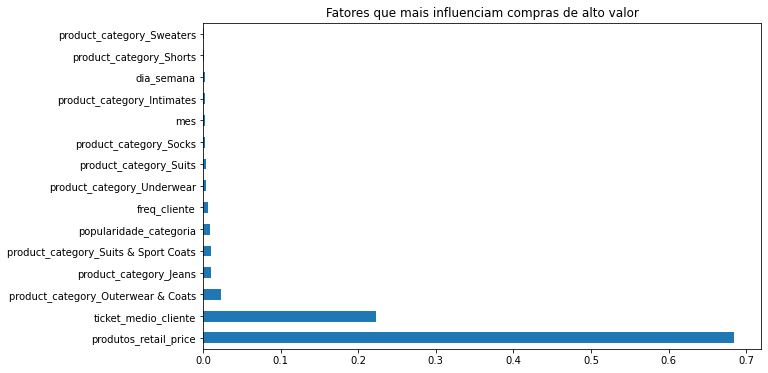

In [74]:
## Insight MAIS IMPORTANTE
import matplotlib.pyplot as plt

importancias = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

importancias.head(15).plot(kind='barh', figsize=(10,6))
plt.title("Fatores que mais influenciam compras de alto valor")
plt.show()